In [ ]:
import sys, os
sys.path.insert(0, os.path.expanduser("~/projects/language-table"))

import nest_asyncio; nest_asyncio.apply()
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML

from language_table.environments.language_table import LanguageTable
from language_table.environments.blocks import LanguageTableBlockVariants
from language_table.environments.rewards.block2block import BlockToBlockReward
from language_table.lamer.gemini_policy import GeminiPolicy
from language_table.lamer.state_to_text import state_to_text


Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
2026-03-25 09:09:00.024258: I tensorflow/core/util/port.cc:110] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-25 09:09:00.044805: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-25 09:09:00.103071: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-25 09:09:00.104550: I tensorflow/core/platform/cpu_feature_guar

In [ ]:
os.environ["GOOGLE_API_KEY"] = ""

In [5]:
env = LanguageTable(
    block_mode=LanguageTableBlockVariants("BLOCK_4"),
    reward_factory=BlockToBlockReward,
    seed=42,
)
policy = GeminiPolicy(
    action_clip=0.1,
    split="none",
    model_id="gemini-3-flash-preview",
    timeout=120,
    )
print("Env and policy ready.")

argv[0]=
Env and policy ready.


In [6]:
async def run_command(command: str, max_steps: int = 200, use_disturbed: bool = False):
    state_text = state_to_text(env._last_state)
    print(f"Current state:\n{state_text}\n")
    print(f"Command: {command}\n")

    result = await policy.translate_async(state_text, command)
    actions = result["disturbed_actions"] if use_disturbed else result["true_actions"]
    print(f"Gemini produced {len(actions)} actions  |  disturbance key: {result['disturbance']}")

    frames = [env.render(mode="rgb_array")]
    total_reward = 0.0
    info = {}

    for i, action in enumerate(actions[:max_steps]):
        obs, reward, done, info = env.step(action)
        frames.append(env.render(mode="rgb_array"))
        total_reward += reward
        if done:
            print(f"  Done at step {i+1}!")
            break

    print(f"\nTotal reward: {total_reward:.3f}  |  Won: {info.get('won', False)}")
    print(f"Final state:\n{state_to_text(env._last_state)}")
    return frames, total_reward, info

def show_rollout(frames, fps=5):
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.axis("off")
    img = ax.imshow(frames[0])
    ax.set_title(f"Rollout  ({len(frames)} frames)")

    def update(i):
        img.set_data(frames[i])
        return [img]

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames),
        interval=1000 / fps, blit=True
    )
    plt.close(fig)
    return HTML(ani.to_jshtml())


Task: push the moon towards the cube
End-effector: (0.314, 0.051)
Blocks: blue_cube (0.406, -0.148), green_star (0.510, 0.139), red_moon (0.315, -0.060), yellow_pentagon (0.428, -0.027)


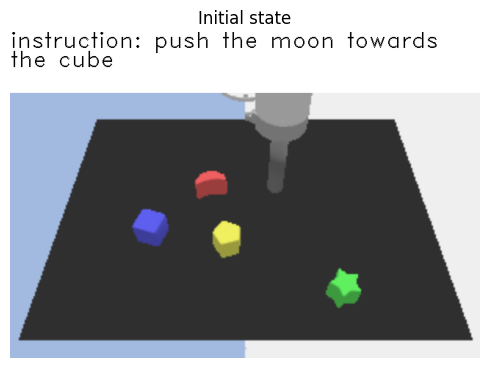

In [7]:
env.reset()
state = env._last_state

print(state_to_text(state))

plt.figure(figsize=(5, 5))
plt.imshow(env.render(mode="rgb_array"))
plt.axis("off")
plt.title("Initial state")
plt.tight_layout()
plt.show()

In [6]:
env.reset()

# frames, reward, info = await run_command("move to the red moon")
# frames, reward, info = await run_command("move behind the green star, then push it to the blue cube")
# frames, reward, info = await run_command(f"move to (0,0)")
frames, reward, info = await run_command(f"move behind the blue cube and push it to the yellow pentagon")

show_rollout(frames)

ERROR:language_table.lamer.gemini_policy:Gemini translate failed after 5 attempts, returning empty actions: GOOGLE_API_KEY env var is not set. Set it in .env.language_table.secrets or export it.


Current state:
Task: push the blue block close to the green block
End-effector: (0.380, 0.022)
Blocks: blue_cube (0.403, 0.190), green_star (0.243, -0.079), red_moon (0.511, 0.124), yellow_pentagon (0.470, -0.064)

Command: move behind the blue cube and push it to the yellow pentagon

Gemini produced 0 actions  |  disturbance key: 

Total reward: 0.000  |  Won: False
Final state:
Task: push the blue block close to the green block
End-effector: (0.380, 0.022)
Blocks: blue_cube (0.403, 0.190), green_star (0.243, -0.079), red_moon (0.511, 0.124), yellow_pentagon (0.470, -0.064)
